# Streaming flow policy with stabilizing conditional flow

In [3]:
import jupyviz as jviz
import matplotlib.pyplot as plt
import numpy as np
import torch; torch.set_default_dtype(torch.double)
from streaming_flow_policy.all import StreamingFlowPolicyASpace
from streaming_flow_policy.toy.plot_aspace import (
    plot_probability_density,
    plot_probability_density_and_vector_field,
    plot_probability_density_and_streamlines,
    plot_probability_density_with_static_trajectories,
    plot_probability_density_and_streamlines_with_animated_trajectories,
)

from pydrake.all import (
    CompositeTrajectory,
    PiecewisePolynomial,
    Trajectory,
)

# Set seed
np.random.seed(0)

## Set hyperparameters

In [4]:
σ0 = 0.05
k = 2.5

# Experimental variable: total opening angle between two branches.
branch_angle_deg = 60.0

# Constants held fixed across all angle conditions.
branch_time = 0.25
angle_measurement_time = 0.50
goal_time = 1.00
goal_action = 0.50

In [5]:
def make_demonstration_traj(
    sign: float,
    angle_deg: float | None = None,
) -> Trajectory:
    """
    Create one branch of a symmetric two-mode trajectory.

    1. Stay at action = 0 until branch_time.
    2. Move along a straight line with the prescribed opening angle
       until angle_measurement_time.
    3. Then smoothly connect to the fixed goal.
    """

    if angle_deg is None:
        angle_deg = branch_angle_deg

    if sign not in (-1.0, +1.0):
        raise ValueError("sign must be -1.0 or +1.0")

    if not 0.0 < angle_deg < 180.0:
        raise ValueError("angle_deg must be between 0 and 180 degrees")

    half_angle_rad = np.deg2rad(angle_deg / 2.0)

    # Straight branch segment.
    delta_t = angle_measurement_time - branch_time
    action_at_measurement = (
        sign * delta_t * np.tan(half_angle_rad)
    )

    if abs(action_at_measurement) >= goal_action:
        raise ValueError(
            f"angle_deg={angle_deg} is too large: "
            f"measurement action={action_at_measurement:.3f}"
        )

    # 1. Shared stem.
    piece_1 = PiecewisePolynomial.FirstOrderHold(
        breaks=[0.0, branch_time],
        samples=[[0.0, 0.0]],
    )

    # 2. Strictly straight branch with the requested angle.
    piece_2 = PiecewisePolynomial.FirstOrderHold(
        breaks=[branch_time, angle_measurement_time],
        samples=[[
            0.0,
            action_at_measurement,
        ]],
    )

    # Velocity at the end of the straight branch.
    branch_velocity = (
        sign * np.tan(half_angle_rad)
    )

    # 3. Smoothly connect from the measurement point to the fixed goal.
    piece_3 = PiecewisePolynomial.CubicWithContinuousSecondDerivatives(
        breaks=[
            angle_measurement_time,
            0.75,
            goal_time,
        ],
        samples=[[
            action_at_measurement,
            sign * 0.42,
            sign * goal_action,
        ]],
        sample_dot_at_start=[[branch_velocity]],
        sample_dot_at_end=[[0.0]],
    )

    return CompositeTrajectory([
        piece_1,
        piece_2,
        piece_3,
    ])


def demonstration_traj_right(
    angle_deg: float | None = None,
) -> Trajectory:
    return make_demonstration_traj(
        sign=+1.0,
        angle_deg=angle_deg,
    )


def demonstration_traj_left(
    angle_deg: float | None = None,
) -> Trajectory:
    return make_demonstration_traj(
        sign=-1.0,
        angle_deg=angle_deg,
    )


traj_right = demonstration_traj_right()
traj_left = demonstration_traj_left()

print(f"Branch angle: {branch_angle_deg:.1f} degrees")
print(f"Right goal: {traj_right.value(goal_time).item():.3f}")
print(f"Left goal:  {traj_left.value(goal_time).item():.3f}")

Branch angle: 60.0 degrees
Right goal: 0.500
Left goal:  -0.500


## Plot demonstration trajectories

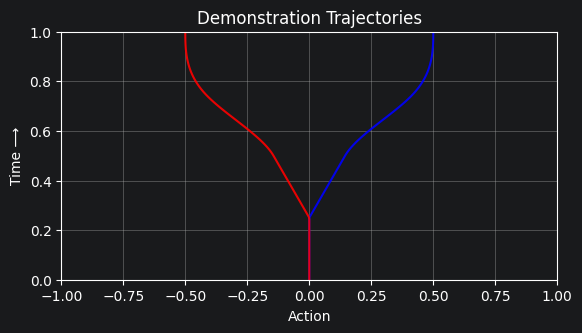

In [6]:
"""
Plot demonstration trajectory on x-y plane where x axis is the state in [-1, 1]
and y axis is the time in [0, 1].
"""
times = np.linspace(0, 1, 100)
plt.plot(traj_right.vector_values(times)[0], times, color='blue', alpha=0.9)
plt.plot(traj_left.vector_values(times)[0], times, color='red', alpha=0.9)
plt.xlim(-1, 1)
plt.ylim(0, 1)
plt.xlabel('Action')
plt.ylabel('Time ⟶')
plt.title('Demonstration Trajectories')

plt.grid(True)
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

## Notation
| Symbol | Space | Meaning |
|:--------:|:-------:|:---------:|
| $t$ | $[0, 1]$ | Time |
| $a$ | $\mathcal{A}$| Action |
| $x = a$ | $\mathcal{A}$ | State (may not equal action in general) |
| $v$ | $T\mathcal{A}$ | Velocity |
| $h$ | $\mathcal{H}$  | Observation history |
| $v_\theta(x, t \mid h)$ | $T\mathcal{A}$ | Learned flow policy |
| $\xi \sim \mathcal{D}$ | $[0, 1] \rightarrow \mathcal{A}$ | Random variable for demonstration trajectories |
| $\xi(t)$ | $\mathcal{A}$ | Action in the demonstration at time $t$ |
| $\dot{\xi}(t)$ | $T\mathcal{A}$ | Velocity in the demonstration at time $t$ |

In this notebook, $x \equiv a$.

### Hyperparameters
| Symbol | Space | Meaning |
|:--------:|:-------:|:---------:|
| $\sigma_0$ | $\mathbb{R}_{\geq 0}$ | Initial standard deviation |
| $k$ | $\mathbb{R}_{\geq 0}$ | Stabilizing gain for the conditional flow |


## Conditional flow

In [7]:
fp = StreamingFlowPolicyASpace(dim=1, trajectories=[traj_right], prior=[1.0], σ0=σ0, k=k)

Given $\xi \sim \mathcal{D}$ with associated observation history $h$, we will define a conditional flow field $v_\theta(x, t \mid h)$ that must be learned.

First, we sample the initial action $a_0$ from a Gaussian centered at the initial action of the demonstration trajectory:

$$
a_0 \sim \mathcal{N}(\xi(0), \sigma_0^2)
$$

where $\sigma_0$ is a small value. Then, the stabilizing velocity field is given by:

$$
\begin{align*}
v(a, t \mid \xi) &= \underbrace{-k(a - \xi(t))}_{\text{Stabilization term}} ~~+~~ \hspace{-1em}\underbrace{\dot{\xi}(t)}_{\text{Path velocity}}
\end{align*}
$$

To solve for the actual flow, we must solve the following ordinary differential equation (ODE):

$$
\begin{align*}
\frac{\mathrm{d}a}{\mathrm{d}t} &= -k(a - \xi(t)) + \dot{\xi}(t)\\
\implies \frac{\mathrm{d}}{\mathrm{d}t} (a - \xi(t)) &= -k(a - \xi(t))\\
\implies a(t \mid \xi) &= \xi(t) ~+~ \hspace{-1em}\underbrace{\left(a_0 - \xi(0)\right) e^{-kt}}_{\text{Error decays exponentially}}
\end{align*}
$$

Due to the stabilizing velocity field, the initial error $(a_0 - \xi(0))$ decays exponentially with time.

Since $a(t \mid \xi)$ is linear in $a_0$, the per-timestep marginal distribution of the conditional flow at any time $t$ is a Gaussian:

$$\mathbb{P}(a \mid t, \xi) = \mathcal{N} \left( a \,\big\vert\, \xi(t)\,,\, \sigma_0^2 e^{-2kt} \right)$$

## Plot conditional probability path of right trajectory

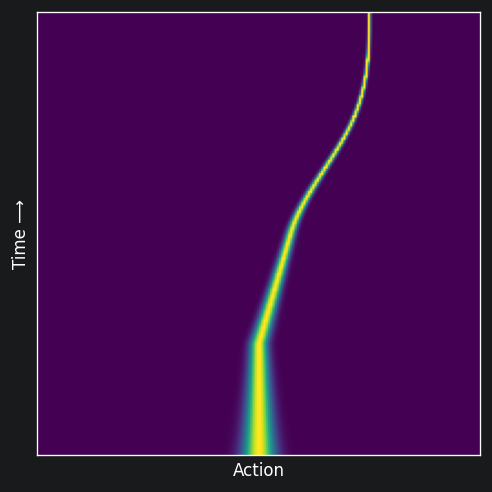

In [8]:
fig, ax = plt.subplots(dpi=120)
ts = torch.linspace(0, 1, 200)  # (T,)
xs = torch.linspace(-1, 1, 200)  # (X,)
ts, xs = torch.meshgrid(ts, xs, indexing='ij')  # (T, X)
plot_probability_density(fp, ts, xs, ax)
# plt.tight_layout()
plt.show()

## Plot conditional vector field of right trajectory

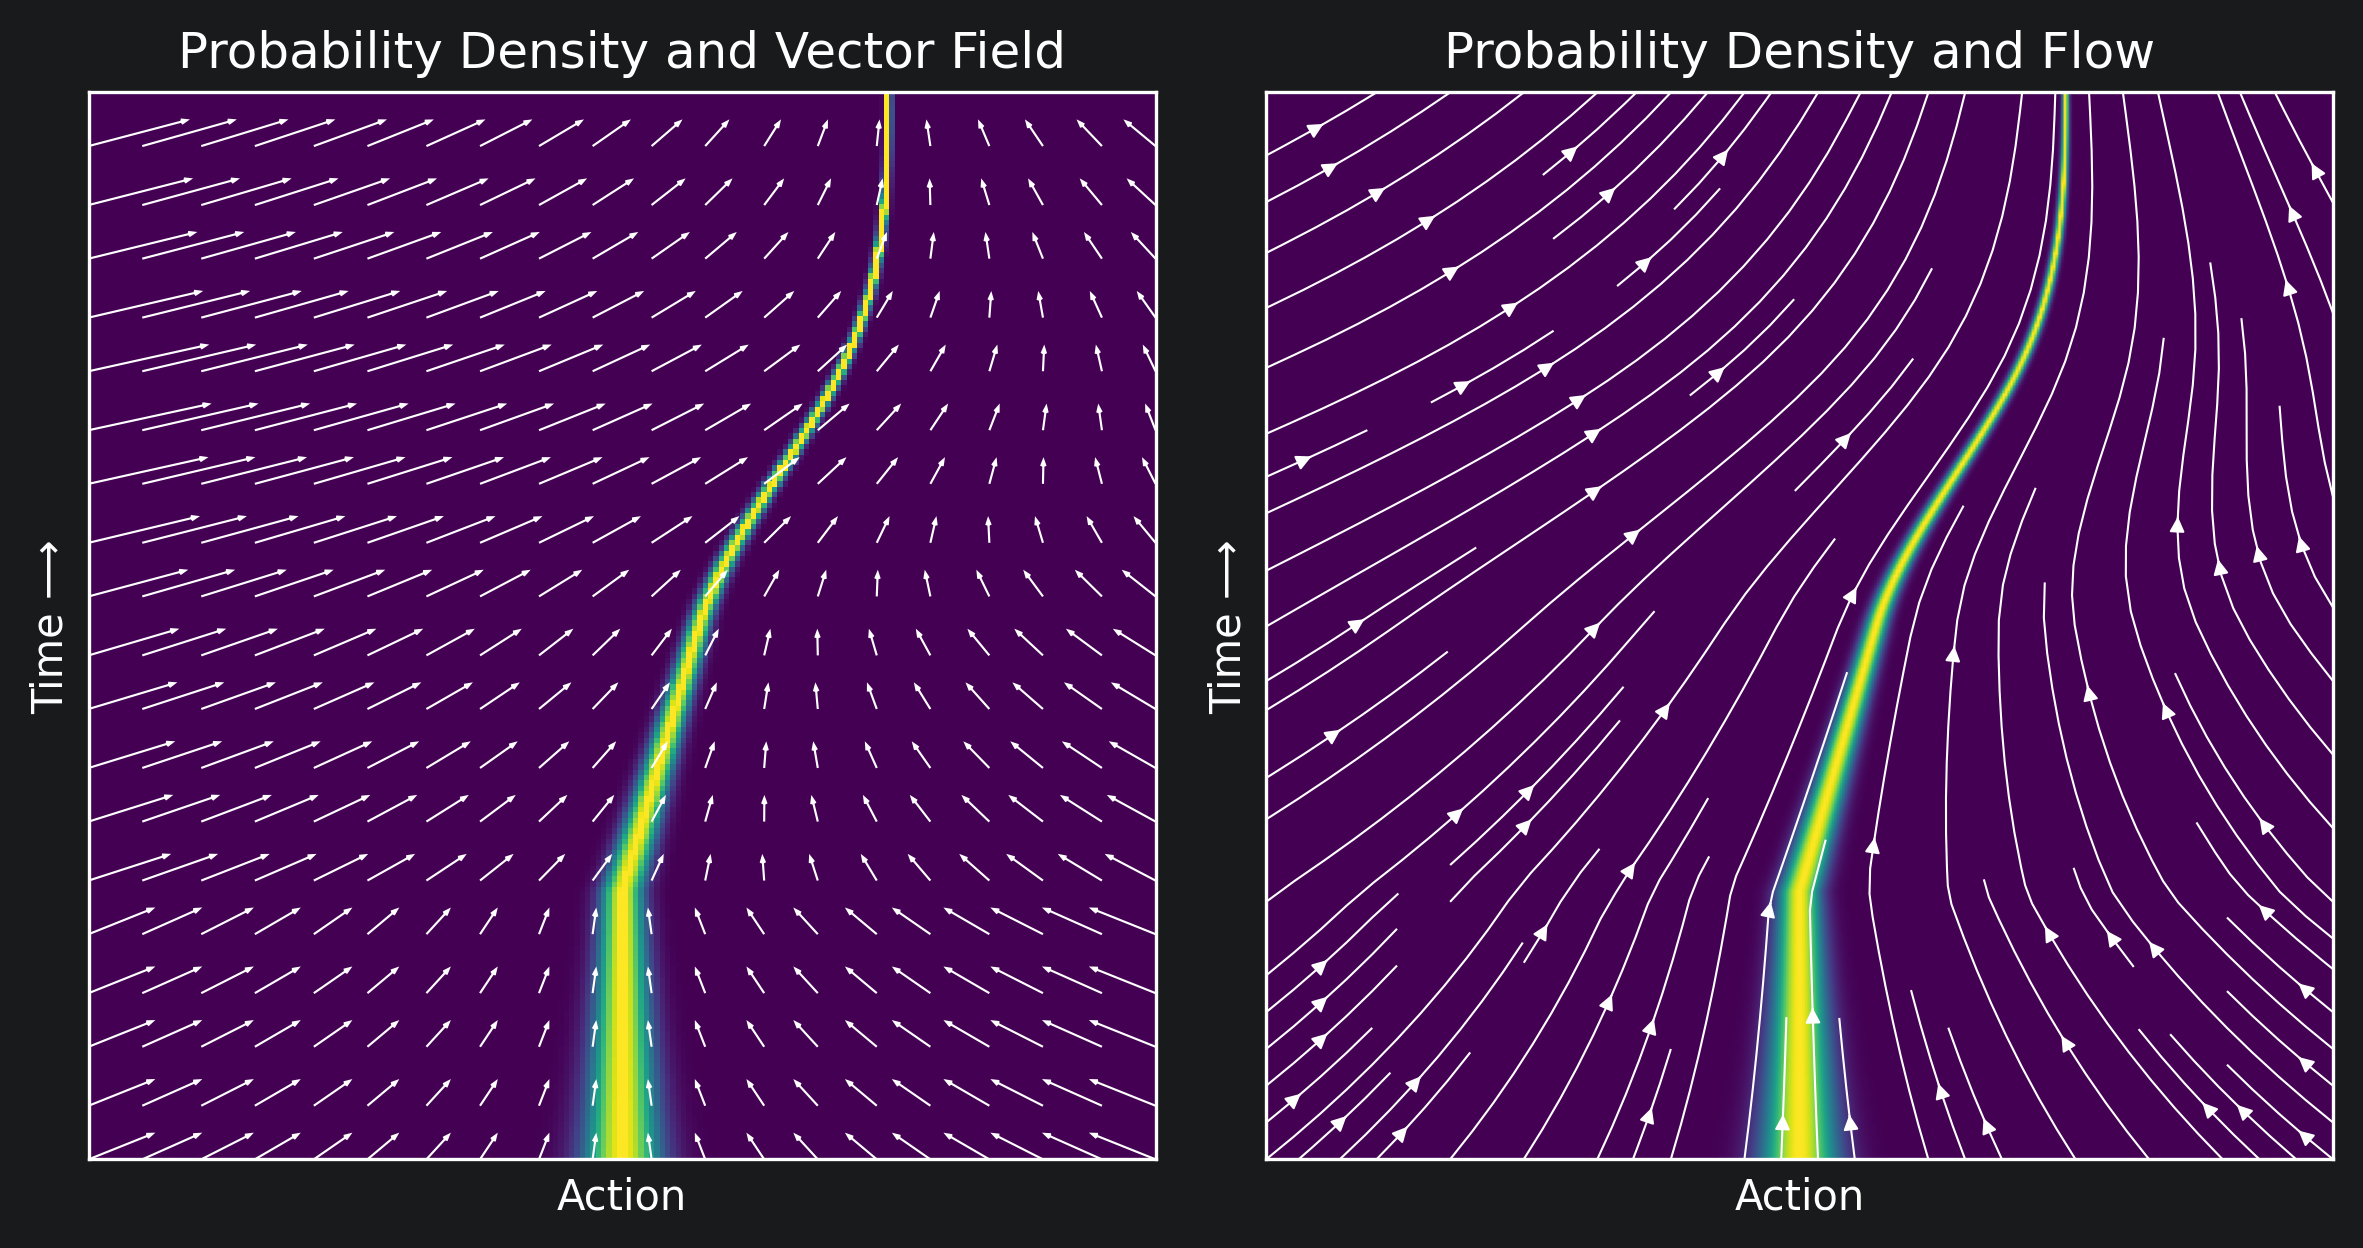

In [9]:
fig = plt.figure(figsize=(8, 4), dpi=300)
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
im1 = plot_probability_density_and_vector_field(fp, ax1)
im2 = plot_probability_density_and_streamlines(fp, ax2)
plt.tight_layout()  # Uncommented to adjust spacing
plt.show()

## Plot trajectories under conditional flow of right trajectory

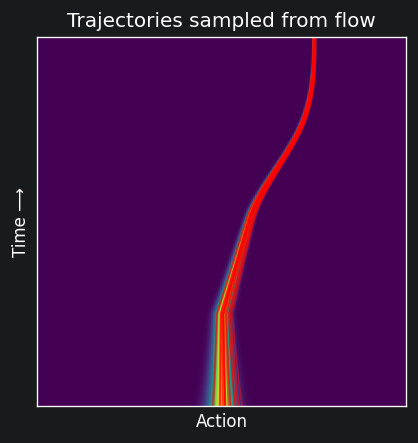

In [10]:
fig, ax = plt.subplots(figsize=(5, 4), dpi=120)
im = plot_probability_density_with_static_trajectories(fp, ax, [None] * 20)
plt.show()

## Marginal flow

In [11]:
fp = StreamingFlowPolicyASpace(dim=1, trajectories=[traj_right, traj_left], prior=[0.5, 0.5], σ0=σ0, k=k)

## Training

Flow matching loss:

$$
\mathcal{L}_\mathrm{FM}(\theta, \mathcal{D}) = \mathbb{E}_{\xi \sim \mathcal{D},\ t,\ a \sim \mathcal{N}\left(\xi(t), \sigma^2\right)} \big\| v_\theta(a, t \mid h) - v(a, t \mid \xi) \big\|_2^2
$$

1. Sample trajectory from dataset $\xi \sim \mathcal{D}$.
2. Define conditional flow $v(a, t \mid \xi) = -k(a - \xi(t)) + \dot{\xi}(t)$.
3. Sample $t \sim \text{Uniform}([0, 1])$.
4. Sample $a \sim \mathcal{N} \left( a \,\big\vert\, \xi(t)\,,\, \sigma_0^2 e^{-2kt} \right)$.
5. Compute L2 loss: $\| v_\theta(a, t \mid h) - v(a, t \mid \xi) \|_2^2$.


## Flow matching theorem

If $v^*(a, t \mid h)$ is the optimal velocity field that minimizes the flow matching loss, then the marginal distributions $\mathbb{P}^*(a \mid t, h)$ induced by $v^*$ at *every* time $t$ is the "average" of the conditional flow distributions $\mathbb{P}(a \mid t, \xi)$ averaged over the training distribution.

$$\mathbb{P}^*(a \mid t, h) = \mathbb{E}_{\xi} \left[ \mathbb{P}(a \mid t, \xi) \right], \ \forall a \in \mathbb{C}, \forall t \in [0, 1]$$

## Plot marginal probability path

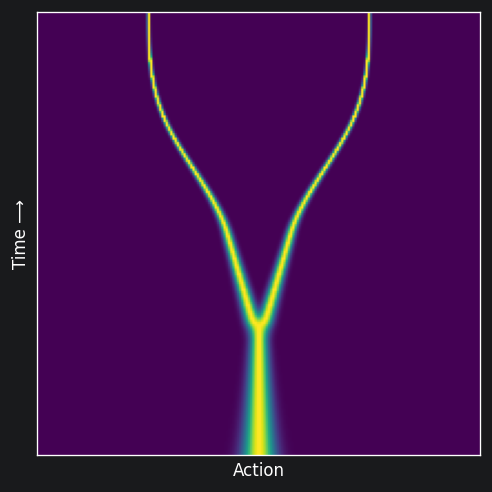

In [12]:
fig, ax = plt.subplots(dpi=120)
ts = torch.linspace(0, 1, 200)  # (T,)
xs = torch.linspace(-1, 1, 200)  # (X,)
ts, xs = torch.meshgrid(ts, xs, indexing='ij')  # (T, X)
plot_probability_density(fp, ts, xs, ax)
# plt.tight_layout()
plt.show()


## Plot marginal vector field

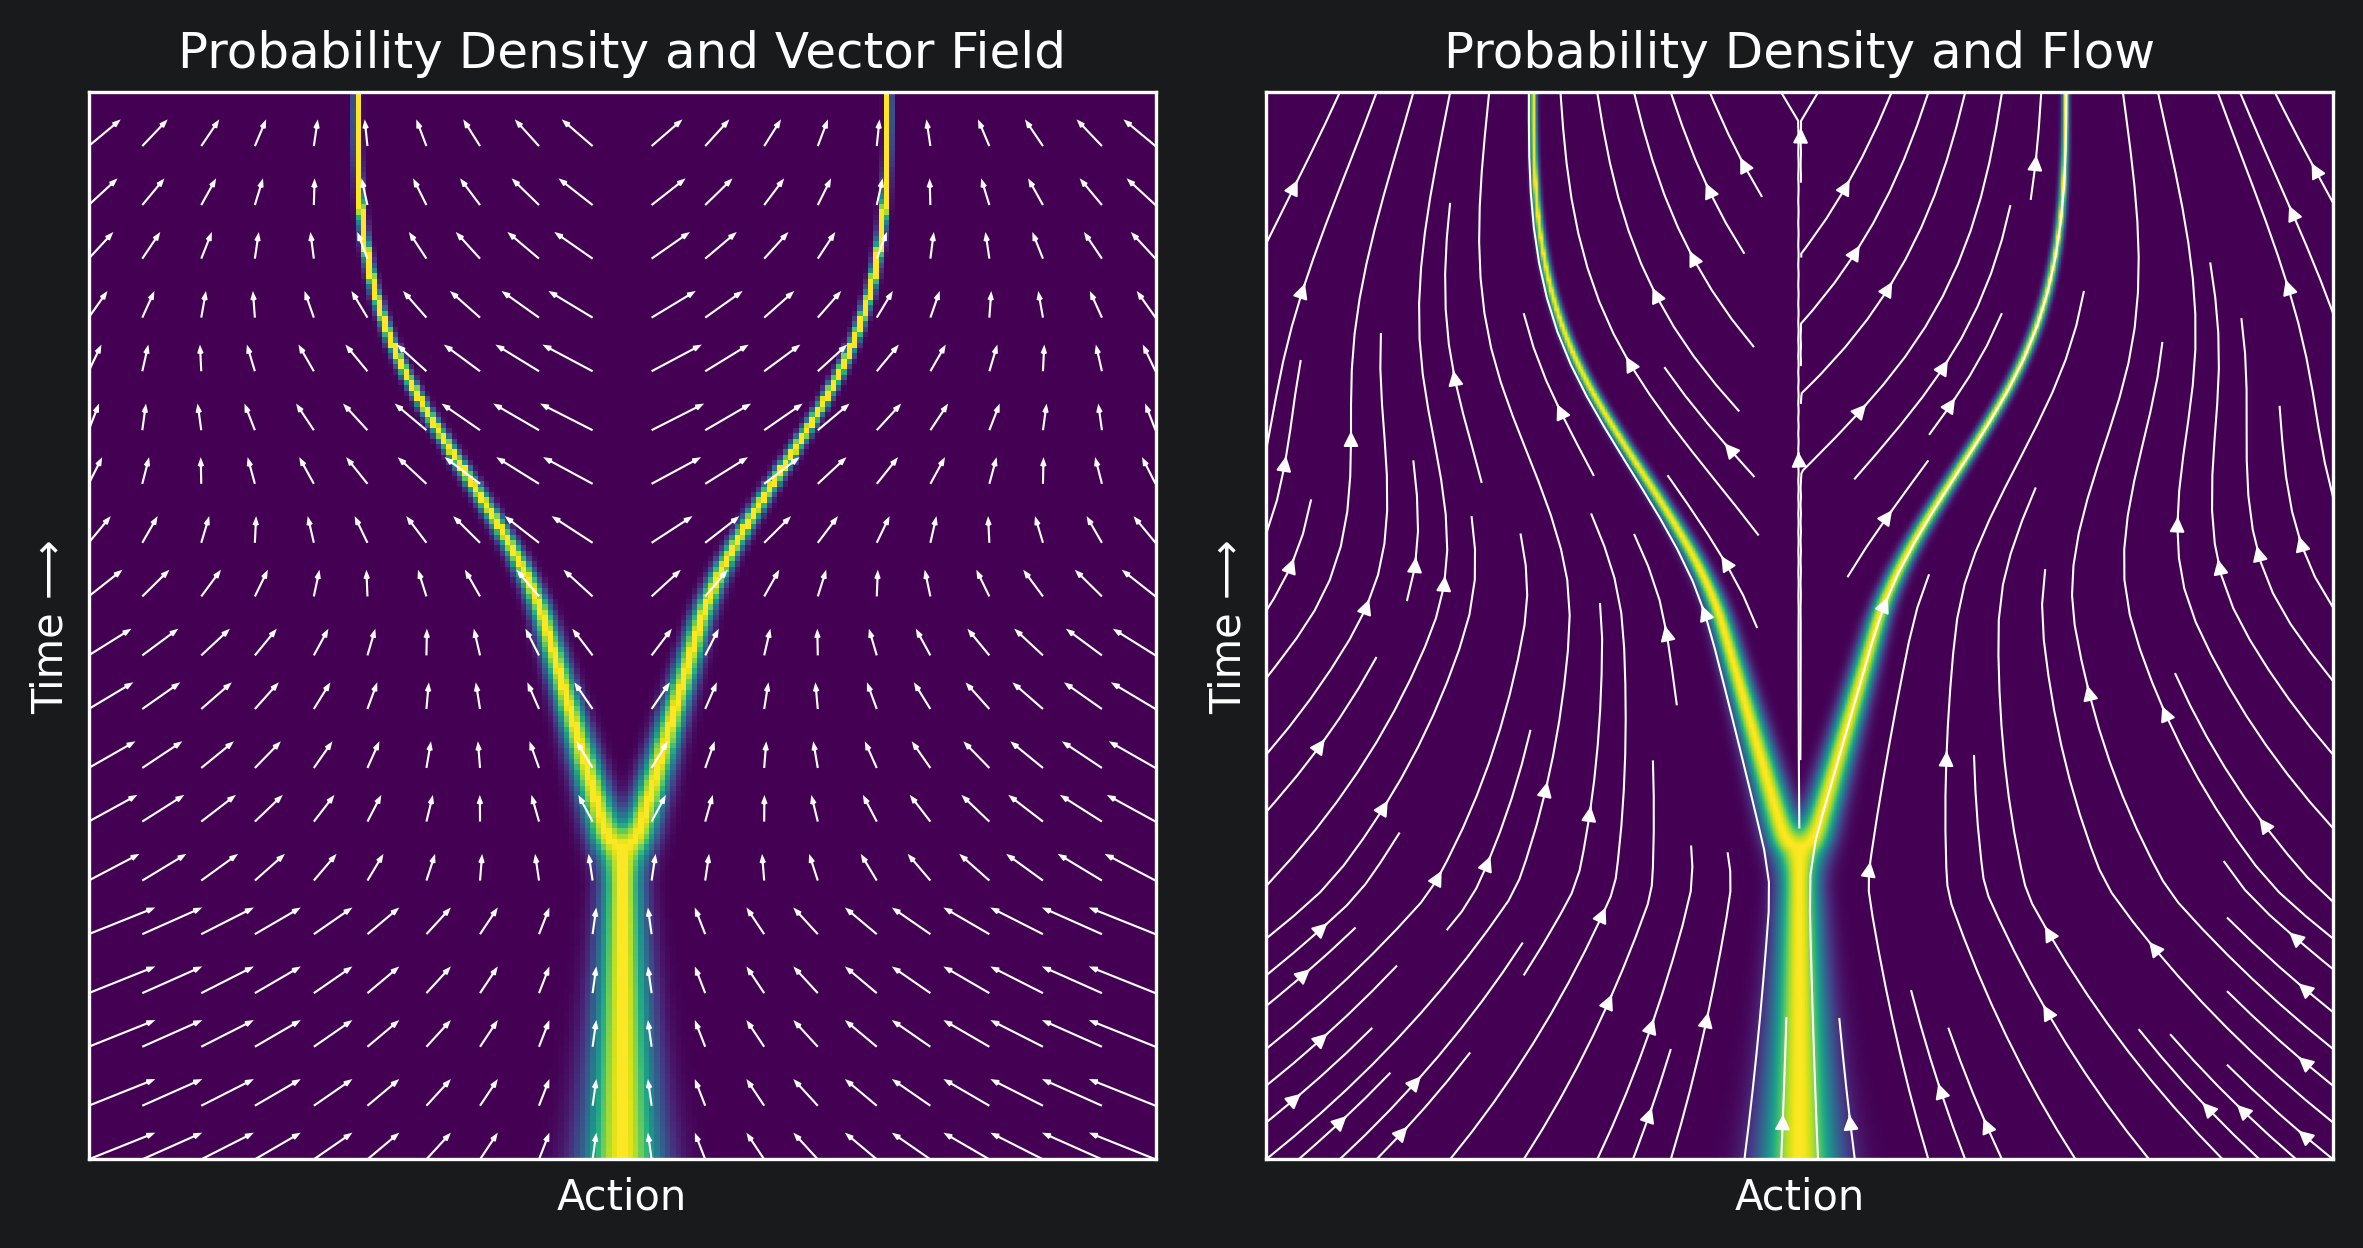

In [13]:
fig = plt.figure(figsize=(8, 4), dpi=300)
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
im1 = plot_probability_density_and_vector_field(fp, ax1)
im2 = plot_probability_density_and_streamlines(fp, ax2)
plt.tight_layout()  # Uncommented to adjust spacing
plt.show()

## Plot trajectories under marginal flow


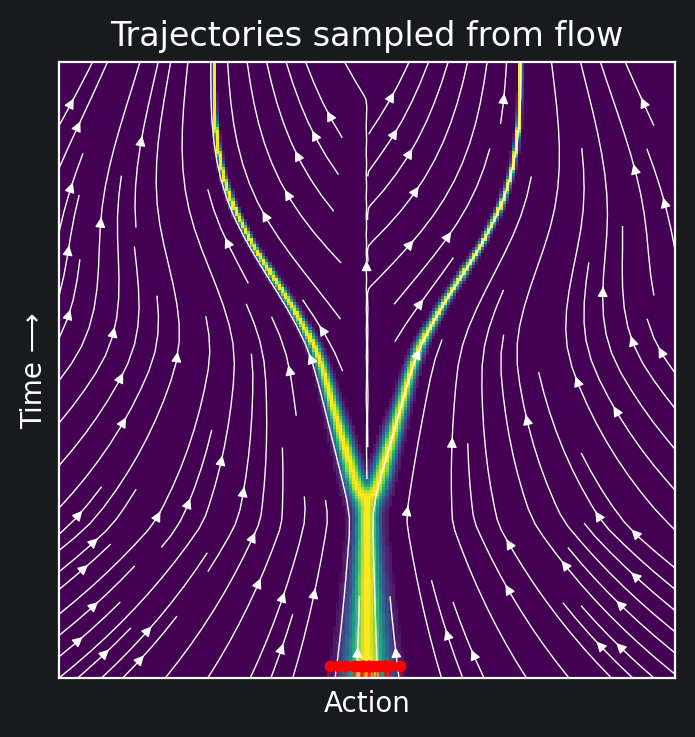

In [14]:
fig, ax = plt.subplots(figsize=(5, 4), dpi=200)
frames = plot_probability_density_and_streamlines_with_animated_trajectories(fp, ax, [None] * 20, num_frames=50, circle_radius=10, dpi=200)
jviz.gif(frames, time_in_ms=3000, hold_last_frame_time_in_ms=1000).html(width=500, pixelated=False).display(); plt.close()

## Pathology when starting from $a=0$

Let us compute the trajectory from the current action $a=0$.

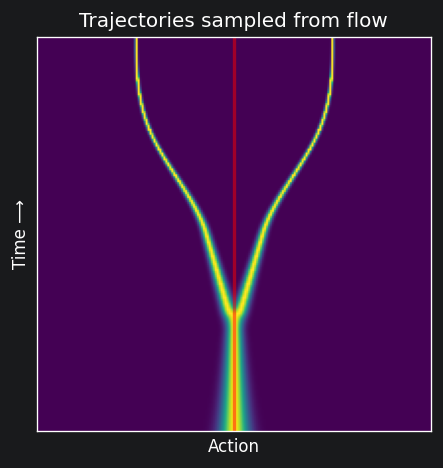

In [15]:
fig, ax = plt.subplots(figsize=(5, 4), dpi=120)
im = plot_probability_density_with_static_trajectories(fp, ax, [0], linewidth=2)
plt.tight_layout()
plt.show()

### Explanation

This is due to:
1. The flow being a deterministic. Which means that for a fixed starting point (i.e. initial action), the trajectory is fixed.
2. In this particular example, the demonstration trajectories are symmetric. This causes the learned velocity field to be zero at $a=0$ for all $t \in [0, 1]$. Therefor, the sampled trajectory is pathological.

The sampled trajectory is not near the demonstration trajectories. Flow matching only guarantees that the marginal distribution of actions is matched at each timestep. Note that the probability of exactly sampling the pathological trajectory is zero, so the flow matching guarantees are satisfied.

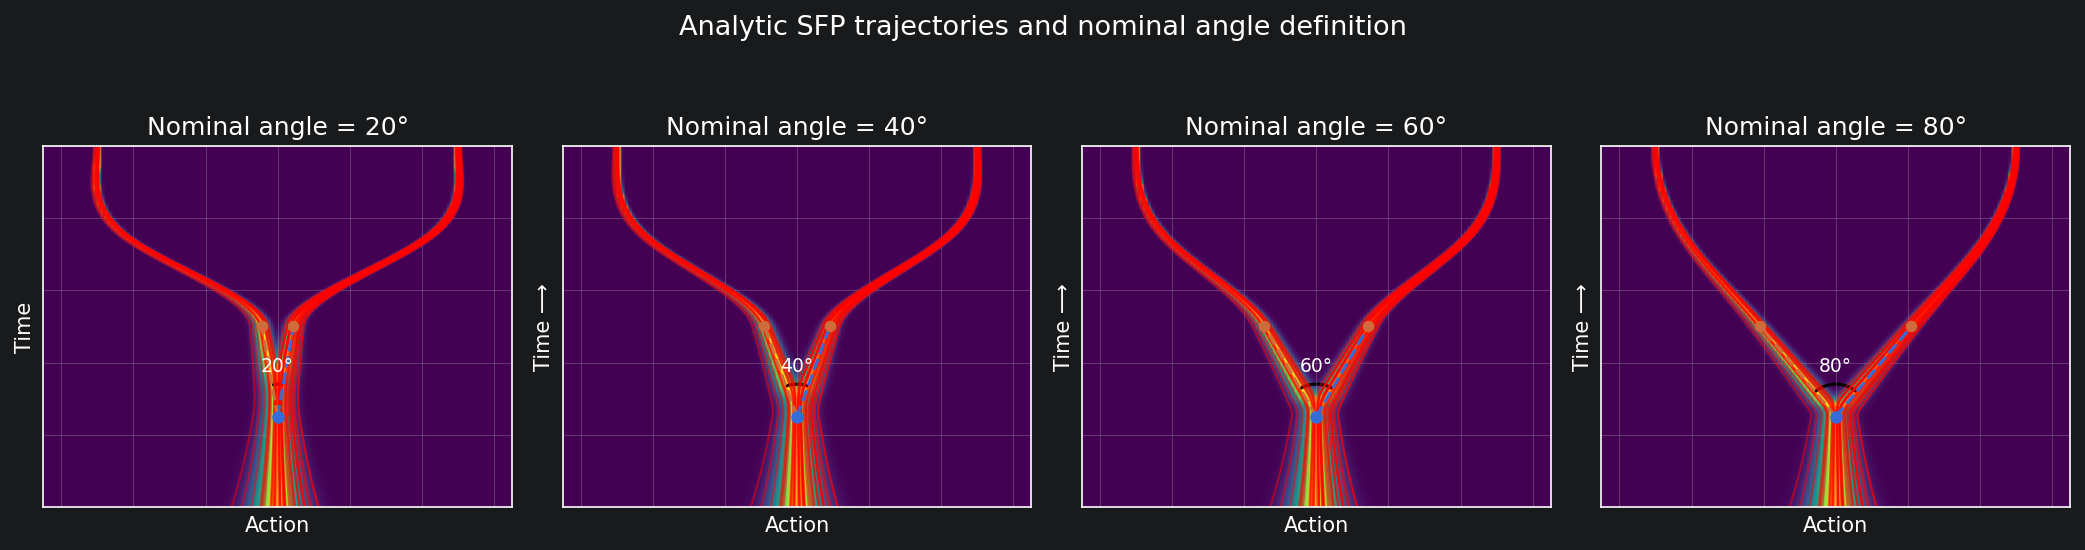

In [16]:
from matplotlib.patches import Arc

# Analytic sweep over different nominal branch angles.
angles_deg = [20.0, 40.0, 60.0, 80.0]
num_samples_per_angle = 40

fig, axes = plt.subplots(
    1,
    len(angles_deg),
    figsize=(14, 4),
    dpi=150,
    sharex=True,
    sharey=True,
)

for ax, angle_deg in zip(axes, angles_deg):
    # Use identical random seeds for every condition.
    np.random.seed(0)
    torch.manual_seed(0)

    right = demonstration_traj_right(angle_deg)
    left = demonstration_traj_left(angle_deg)

    policy = StreamingFlowPolicyASpace(
        dim=1,
        trajectories=[right, left],
        prior=[0.5, 0.5],
        σ0=σ0,
        k=k,
    )

    # Plot SFP density and trajectories.
    plot_probability_density_with_static_trajectories(
        policy,
        ax,
        [None] * num_samples_per_angle,
        linewidth=1,
    )

    # ---------------------------------------------------------
    # Show how the nominal branch angle is actually defined.
    # ---------------------------------------------------------

    # Branch point in (action, time) coordinates.
    branch_point = np.array([0.0, branch_time])

    # Positions of the two expert trajectories at the
    # angle-measurement time.
    right_measurement = np.array([
        right.value(angle_measurement_time).item(),
        angle_measurement_time,
    ])

    left_measurement = np.array([
        left.value(angle_measurement_time).item(),
        angle_measurement_time,
    ])

    # Draw the two chords used to define the nominal angle.
    ax.plot(
        [branch_point[0], right_measurement[0]],
        [branch_point[1], right_measurement[1]],
        "--",
        linewidth=1.5,
        label="Angle-defining chord",
    )

    ax.plot(
        [branch_point[0], left_measurement[0]],
        [branch_point[1], left_measurement[1]],
        "--",
        linewidth=1.5,
    )

    # Mark branch point and measurement points.
    ax.scatter(
        branch_point[0],
        branch_point[1],
        s=25,
        zorder=5,
    )

    ax.scatter(
        [left_measurement[0], right_measurement[0]],
        [left_measurement[1], right_measurement[1]],
        s=20,
        zorder=5,
    )

    # Add an arc showing the nominal opening angle.
    arc_radius = 0.09

    # Angle is symmetric around the vertical time axis.
    theta1 = 90 - angle_deg / 2
    theta2 = 90 + angle_deg / 2

    arc = Arc(
        branch_point,
        width=2 * arc_radius,
        height=2 * arc_radius,
        angle=0,
        theta1=theta1,
        theta2=theta2,
        linewidth=1.5,
    )
    ax.add_patch(arc)

    # Angle label.
    ax.text(
        branch_point[0],
        branch_point[1] + arc_radius + 0.025,
        f"{angle_deg:.0f}°",
        ha="center",
        va="bottom",
        fontsize=9,
    )

    ax.set_title(f"Nominal angle = {angle_deg:.0f}°")
    ax.set_xlim(-0.65, 0.65)
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Action")
    ax.grid(True, alpha=0.3)

    # Important: preserves the visual meaning of angle
    # in the action-time plot.
    ax.set_aspect("equal", adjustable="box")

axes[0].set_ylabel("Time")

fig.suptitle(
    "Analytic SFP trajectories and nominal angle definition",
    fontsize=13,
)

plt.tight_layout()
plt.show()

In [17]:
def evaluate_analytic_policy(
    angle_deg: float,
    initial_actions: np.ndarray,
    ode_steps: int = 1000,
) -> dict:
    """
    Evaluate terminal accuracy of the exact analytic marginal flow.
    The same initial actions should be reused for every angle.
    """
    right = demonstration_traj_right(angle_deg)
    left = demonstration_traj_left(angle_deg)

    policy = StreamingFlowPolicyASpace(
        dim=1,
        trajectories=[right, left],
        prior=[0.5, 0.5],
        σ0=σ0,
        k=k,
    )

    x_starts = torch.tensor(
        initial_actions,
        dtype=torch.double,
    ).reshape(-1, 1)

    sampled_trajectories = policy.ode_integrate(
        x_starts,
        num_steps=ode_steps,
    )

    final_actions = np.array([
        trajectory.vector_values([goal_time])[0, 0]
        for trajectory in sampled_trajectories
    ])

    # Distance to the nearest valid endpoint: either -0.5 or +0.5.
    endpoint_errors = np.minimum(
        np.abs(final_actions - goal_action),
        np.abs(final_actions + goal_action),
    )

    # Whether the final mode agrees with the sign of the initial sample.
    sign_preserved = np.sign(final_actions) == np.sign(initial_actions)

    return {
        "angle_deg": angle_deg,
        "num_samples": len(final_actions),
        "success_001": np.mean(endpoint_errors <= 0.01),
        "success_005": np.mean(endpoint_errors <= 0.05),
        "mean_error": np.mean(endpoint_errors),
        "median_error": np.median(endpoint_errors),
        "p95_error": np.quantile(endpoint_errors, 0.95),
        "max_error": np.max(endpoint_errors),
        "right_fraction": np.mean(final_actions > 0),
        "sign_preservation": np.mean(sign_preserved),
        "final_actions": final_actions,
        "endpoint_errors": endpoint_errors,
    }

In [75]:
evaluation_angles = [20.0, 40.0, 60.0, 80.0]
num_evaluation_samples = 1000
evaluation_seed = 0

# Generate the initial samples only once.
# Every angle receives exactly the same initial actions.
rng = np.random.default_rng(evaluation_seed)
shared_initial_actions = rng.normal(
    loc=0.0,
    scale=σ0,
    size=num_evaluation_samples,
)

analytic_results = [
    evaluate_analytic_policy(
        angle_deg=angle,
        initial_actions=shared_initial_actions,
        ode_steps=1000,
    )
    for angle in evaluation_angles
]

header = (
    f"{'Angle':>7} "
    f"{'Success@.01':>13} "
    f"{'Success@.05':>13} "
    f"{'Mean error':>12} "
    f"{'P95 error':>11} "
    f"{'Max error':>11} "
    f"{'Right %':>9} "
    f"{'Sign kept':>11}"
)

print(header)
print("-" * len(header))

for result in analytic_results:
    print(
        f"{result['angle_deg']:>6.0f}° "
        f"{result['success_001']:>12.2%} "
        f"{result['success_005']:>12.2%} "
        f"{result['mean_error']:>12.6f} "
        f"{result['p95_error']:>11.6f} "
        f"{result['max_error']:>11.6f} "
        f"{result['right_fraction']:>8.2%} "
        f"{result['sign_preservation']:>10.2%}"
    )

  Angle   Success@.01   Success@.05   Mean error   P95 error   Max error   Right %   Sign kept
----------------------------------------------------------------------------------------------
    20°       98.30%      100.00%     0.003203    0.008111    0.015515   46.60%    100.00%
    40°       98.30%      100.00%     0.003207    0.008100    0.015503   46.60%    100.00%
    60°       98.30%      100.00%     0.003211    0.008102    0.015490   46.60%    100.00%
    80°       98.20%      100.00%     0.003216    0.008150    0.015473   46.60%    100.00%
